In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Tabpfn import train_tabpfn
from simulate_missingness import (
    selection_mar_logistic,
    selection_mnar_on_y,
    test_mnar_vs_mar,
    compare_distributions
)

In [2]:
rng = np.random.default_rng(42)
n = 2000
k = 4
X = rng.normal(size=(n, k))
# give columns friendly names
col_names = [f"X{i}" for i in range(k)]
df = pd.DataFrame(X, columns=col_names)
# Build a label 'BAD' correlated with features (rough signal)
coefs = np.array([0.8, -1.2, 0.4, 0.2])
logit = df.values @ coefs
p_bad = 1 / (1 + np.exp(- (logit - 0.2)))
df['BAD'] = (rng.random(n) < p_bad).astype(int)

In [3]:
mask_mar, probs_mar = selection_mar_logistic(df, col_names, rng, intercept=-0.5, stochastic=True)
print("MAR diagnostic:")
test_mnar_vs_mar(df, mask_mar, col_names)

# 3) Run MNAR selection (depends on true label Y)
mask_mnar, probs_mnar = selection_mnar_on_y(df, col_names, rng, beta_y=1.8, intercept=-1.0, stochastic=True)
print("MNAR diagnostic:")
test_mnar_vs_mar(df, mask_mnar, col_names)

MAR diagnostic:
[diagnostic] logistic R ~ X + Y: coef on Y = -0.0168  --> MAR-like (small)
[diagnostic] P(R=1 | Y=1) = 0.460, P(R=1 | Y=0) = 0.529
MNAR diagnostic:
[diagnostic] logistic R ~ X + Y: coef on Y = 0.9725  --> MNAR-like
[diagnostic] P(R=1 | Y=1) = 0.768, P(R=1 | Y=0) = 0.261


{'coef_y': 0.972512865765444}


Mean differences (MAR): {'X0': -0.08387680714541867, 'X1': 0.2455561370815733, 'X2': 0.40008452798071686, 'X3': -0.04759580884807358}
Mean differences (MNAR): {'X0': 0.053668018956050695, 'X1': -0.4577721000622626, 'X2': 0.0232237578314855, 'X3': 0.06596668392852857}


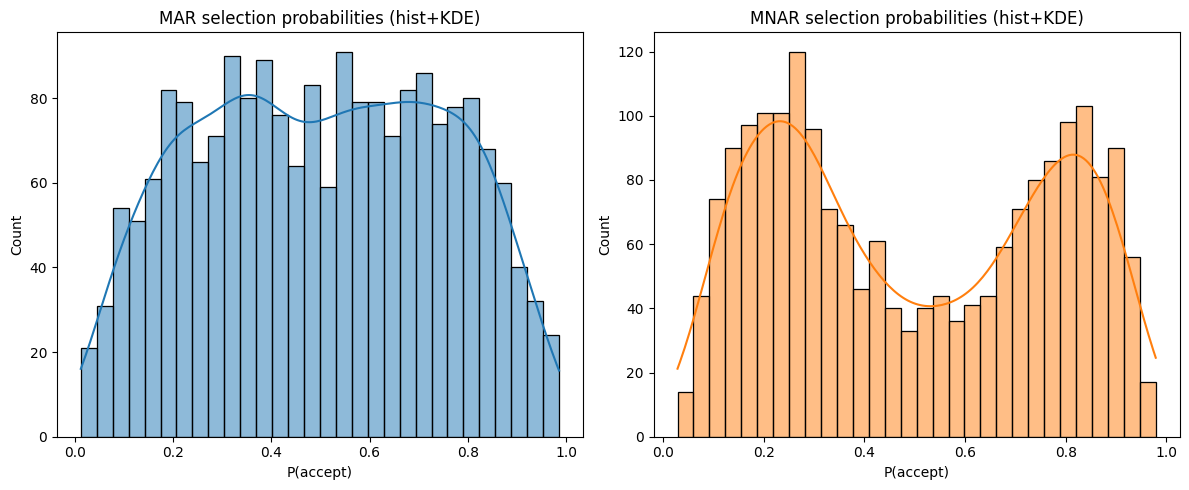

In [4]:
# 4) Quick distribution compare (accepted vs population)
diffs_mar = compare_distributions(df, mask_mar, col_names)
diffs_mnar = compare_distributions(df, mask_mnar, col_names)
print("\nMean differences (MAR):", {c: diffs_mar[c]['acc_mean'] - diffs_mar[c]['pop_mean'] for c in col_names})
print("Mean differences (MNAR):", {c: diffs_mnar[c]['acc_mean'] - diffs_mnar[c]['pop_mean'] for c in col_names})

# 5) Plot selection probabilities and KDEs for illustration
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.histplot(probs_mar, bins=30, kde=True, color='C0')
plt.title('MAR selection probabilities (hist+KDE)')
plt.xlabel('P(accept)')

plt.subplot(1,2,2)
sns.histplot(probs_mnar, bins=30, kde=True, color='C1')
plt.title('MNAR selection probabilities (hist+KDE)')
plt.xlabel('P(accept)')
plt.tight_layout()
plt.show()

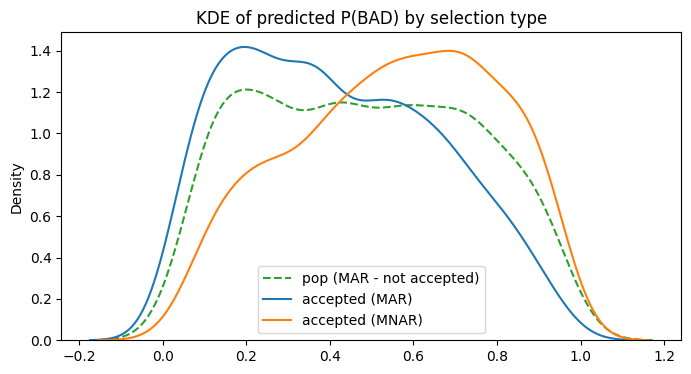

In [5]:
# 6) KDE of model-implied P(BAD) for accepted vs population (use simple logistic model using X)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[col_names].values)
clf = LogisticRegression().fit(X_scaled, df['BAD'].values)
probs_all = clf.predict_proba(X_scaled)[:, 1]

plt.figure(figsize=(8,4))
sns.kdeplot(probs_all[df.index[~mask_mar]], label='pop (MAR - not accepted)', color='C2', linestyle='--')
sns.kdeplot(probs_all[df.index[mask_mar]], label='accepted (MAR)', color='C0')
sns.kdeplot(probs_all[df.index[mask_mnar]], label='accepted (MNAR)', color='C1')
plt.title('KDE of predicted P(BAD) by selection type')
plt.legend()
plt.show()

In [ ]:
import data_generator_update as data2

res = data2.DataGenerator2(
    n = 1000,
    k_con = 10,
    k_bin = 1,
    bad_ratio = 0.8,
    con_mean_bad_dif = [-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8],
    con_nonlinear = 0,
    covars = None,
    seed = 100,
    coef_scale = 1.0,    # keep reasonable signal in features -> labels
    noise_scale = 1.0,   # do not add extra noise so labels remain meaningful
    flip_frac = 0.0,     # NO label flips (clean labels)
    verbose = True
)
df_full = res.generate()



Generating 10 continuous features with 1 binary features
Simulating (1000 x 11) data set
Generated dataset with n=1000, k_con=10, k_bin=1
BAD prevalence (approx): 0.7960 (target 0.8)
coef_scale=1.0, noise_scale=1.0, flip_frac=0.0
Generating 10 continuous features with 1 binary features
Simulating (1000 x 11) data set
Generated dataset with n=1000, k_con=10, k_bin=1
BAD prevalence (approx): 0.7950 (target 0.8)
coef_scale=1.0, noise_scale=1.0, flip_frac=0.0
Generating 10 continuous features with 1 binary features
Simulating (1000 x 11) data set
Generated dataset with n=1000, k_con=10, k_bin=1
BAD prevalence (approx): 0.7990 (target 0.8)
coef_scale=1.0, noise_scale=1.0, flip_frac=0.0


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,BAD,B1
0,0.023807,1.207857,-0.819840,0.277640,-0.861094,-0.553948,-0.202861,-0.129126,-0.322076,-2.933709,BAD,0
1,-1.383195,-0.838276,0.714050,2.069488,1.233903,-1.244200,1.532915,0.499552,0.248906,0.286327,BAD,1
2,-0.519459,-0.260298,1.590911,-0.603463,-0.858116,-1.402676,-0.502016,-0.531466,0.883936,1.053548,BAD,0
3,-0.387439,0.323900,1.184139,-0.402389,0.931842,0.086718,2.214570,0.638949,0.255929,1.521676,BAD,0
4,0.267220,1.067373,-0.441312,-1.058471,0.124550,0.386123,1.727239,1.072194,-0.083804,-0.713498,BAD,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.331463,-0.085414,-0.047080,-0.689763,-1.149682,-0.655970,1.420179,-0.368360,1.765026,-1.082509,BAD,1
996,-1.464740,-0.390885,-0.357562,-0.929803,0.543418,-0.303352,-0.052621,0.086754,-0.821576,-1.589962,BAD,0
997,0.347166,0.237454,0.875427,-0.070722,-0.573722,0.191396,-1.063240,1.660451,0.491569,-0.040149,BAD,0
998,-1.203396,-1.127386,-0.003637,0.167809,-1.243629,-0.183048,-0.040194,-1.763272,-0.511952,0.523191,BAD,1


In [65]:
df_full['Y'] = df_full['BAD'].map({'GOOD':0,'BAD':1}).astype(int)

# Create a beta_x vector aligned to the business_score: put weights on first len(features) features,
# zeros for remaining features (so selection's X-part equals this business_score)

# features and weights (user-specified)
features = ['X1', 'X2', 'X3', 'X4', 'X5']
weights = np.array([0.5, 0.3, 0.1, 0.05, 0.05], dtype=float)

all_X_cols = [c for c in df_full.columns if c.startswith('X')]
n_all = len(all_X_cols)
beta_x = np.zeros(n_all, dtype=float)
# map the business_score weights into beta_x positions for X1..X5
for i, f in enumerate(features):
    beta_x[i] = weights[i]

seed = 12345
np.random.seed(seed)
beta_y = -0.5         # negative => BAD (Y=1) less likely to be accepted
top_percent = 0.20
# --- MNAR selection: deterministic top-20% by (X-part + beta_y * Y)
df_full_mnar, df_obs_mnar = res.impose_selection(mode='MNAR', top_percent=top_percent, beta_x=beta_x,
                                                 beta_y=beta_y, probabilistic=True, stochastic=True, rng_seed=seed)

# --- MNAR + Mixed 
alpha=0.2 #20% of the score is Y-term
df_full_mix, df_obs_mix = res.impose_selection(mode='MIXED',
                                              top_percent=top_percent,
                                              beta_x=beta_x,
                                              beta_y=beta_y,
                                              alpha=alpha,
                                              probabilistic=False,
                                              stochastic=False,
                                              rng_seed=seed)

# quick diagnostics
print("Total:", len(df_full_mix), "Accepted:", int(df_obs_mix['S'].sum()))
print("P(R=1 | Y):", df_obs_mix.groupby('Y')['S'].mean().to_dict())
print("Accepted counts by Y:", df_obs_mix[df_obs_mix['S']==1]['Y'].value_counts().to_dict())



Total: 1000 Accepted: 200
P(R=1 | Y): {0: 0.21890547263681592, 1: 0.19524405506883605}
Accepted counts by Y: {1: 156, 0: 44}


In [70]:
if 'business_score' not in df_full_mnar.columns:
    scaler = StandardScaler().fit(df_full_mnar[features].astype(float).values)
    Xz = scaler.transform(df_full_mnar[features].astype(float).values)
    w = np.ones(len(features)) / len(features)
    df_full_mnar['business_score'] = Xz.dot(w)


    
# copy score into observed frame (indices were preserved)
n_total = len(df_full_mnar)
n_accept = int(df_obs_mnar['S'].sum())
n_reject = n_total - n_accept
print(f"Total: {n_total}, Accepted: {n_accept} ({n_accept/n_total:.2%}), Rejected: {n_reject}")

print("\nAccepted counts by true label (Y):")
print(df_obs_mnar[df_obs_mnar['S']==1]['Y'].value_counts().to_dict())

print("\nP(R=1 | Y):")
print(df_obs_mnar.groupby('Y')['S'].mean().to_dict())

Total: 1000, Accepted: 200 (20.00%), Rejected: 800

Accepted counts by true label (Y):
{1: 129, 0: 71}

P(R=1 | Y):
{0: 0.35323383084577115, 1: 0.16145181476846057}


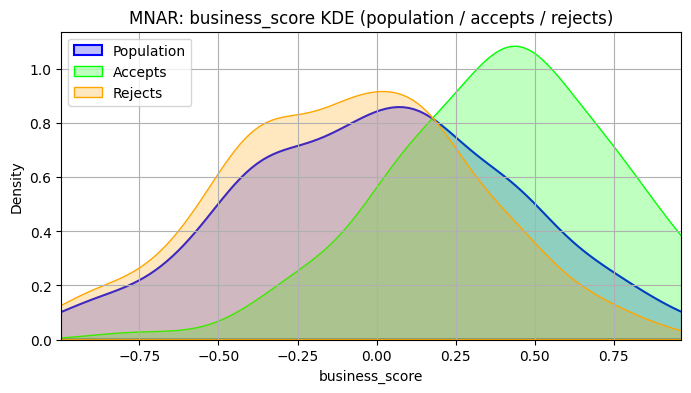

In [73]:
# KDEs: population / accepts / rejects
df_obs_mnar = df_obs_mnar.copy()
df_obs_mnar['business_score'] = df_full_mnar['business_score'].values
plt.figure(figsize=(8,4))
sns.kdeplot(df_full_mnar['business_score'], fill=True, label='Population', color='blue', lw=1.5)
sns.kdeplot(df_obs_mnar.loc[df_obs_mnar['S']==1,'business_score'], fill=True,label='Accepts', color='lime')
sns.kdeplot(df_obs_mnar.loc[df_obs_mnar['S']==0,'business_score'], fill=True,label='Rejects', color='orange')
plt.title('MNAR: business_score KDE (population / accepts / rejects)')
plt.xlabel('business_score')
plt.legend()
plt.grid(True)
plt.xlim(df_full_mnar['business_score'].quantile(0.01), df_full_mnar['business_score'].quantile(0.99))
plt.show()

In [67]:
scaler = StandardScaler().fit(df_full_mix[features].astype(float).values)
Xz = scaler.transform(df_full_mix[features].astype(float).values)
w = np.ones(len(features)) / len(features)
df_full_mix['business_score'] = Xz.dot(w)
df_obs_mix['business_score'] = df_full_mix['business_score'].values

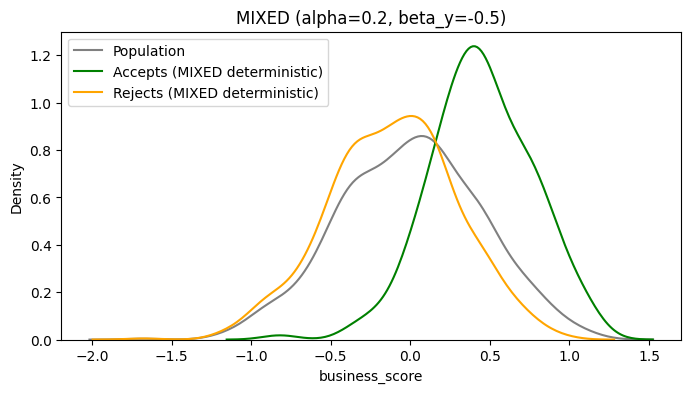

In [68]:
plt.figure(figsize=(8,4))
sns.kdeplot(df_full_mix['business_score'], label='Population', color='gray')
sns.kdeplot(df_obs_mix.loc[df_obs_mix['S']==1,'business_score'], label='Accepts (MIXED deterministic)', color='green')
sns.kdeplot(df_obs_mix.loc[df_obs_mix['S']==0,'business_score'], label='Rejects (MIXED deterministic)', color='orange')
plt.legend(); plt.title(f"MIXED (alpha={alpha}, beta_y={beta_y})"); plt.show()

In [74]:
holdout = data2.DataGenerator2(n=2000, replicate=res, seed=99999, verbose=False)
holdout.generate()
holdout_df = holdout.data.copy()

In [76]:
mask_mnar_accept = df_obs_mnar['S'] == 1 
mask_mnar_reject = df_obs_mnar['S'] == 0
X_train = df_obs_mnar.loc[mask_mnar_accept, features].astype(float).values
y_train = df_obs_mnar.loc[mask_mnar_accept, 'BAD'].map({'GOOD':0,'BAD':1}).astype(int).values
X_hold  = holdout_df[features].astype(float).values

probs_hold, tabpfn_model = train_tabpfn(X_train, y_train, X_hold, timeout_minutes=30, seed=42, verbose=1)

Training TabPFN on 200 samples, evaluating on 2000 samples.


Holdout prevalence: 0.5085
Baseline Brier (always predict p0): 0.24992775
Holdout AUC: 0.6746269671935189 Brier: 0.3371198226025746


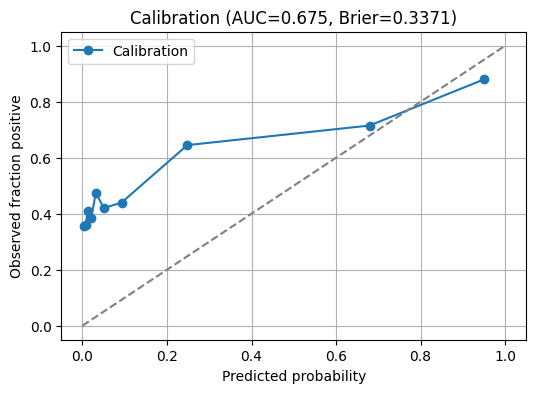

In [77]:
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
# probs_hold returned from train_tabpfn
y_hold = holdout_df['BAD'].map({'GOOD':0,'BAD':1}).astype(int).values

p0 = y_hold.mean()                     # holdout prevalence
brier_baseline = p0*(1-p0)**2 + (1-p0)*(p0**2)
print("Holdout prevalence:", p0)
print("Baseline Brier (always predict p0):", brier_baseline) 

auc = roc_auc_score(y_hold, probs_hold)
brier = brier_score_loss(y_hold, probs_hold)
print("Holdout AUC:", auc, "Brier:", brier)

# calibration plot
prob_true, prob_pred = calibration_curve(y_hold, probs_hold, n_bins=10, strategy='quantile')
plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration')
plt.plot([0,1],[0,1], '--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('Observed fraction positive')
plt.title(f'Calibration (AUC={auc:.3f}, Brier={brier:.4f})')
plt.grid(True); plt.legend(); plt.show()

In [78]:
mask_mix_accept = df_obs_mix['S']==1
mask_mix_reject = df_obs_mix['S'] == 0
X_train = df_obs_mix.loc[mask_mix_accept, features].astype(float).values
y_train = df_obs_mix.loc[mask_mix_accept, 'BAD'].map({'GOOD':0,'BAD':1}).astype(int).values
X_hold  = holdout_df[features].astype(float).values

probs_hold, tabpfn_model = train_tabpfn(X_train, y_train, X_hold, timeout_minutes=30, seed=42, verbose=1)

Training TabPFN on 200 samples, evaluating on 2000 samples.


Holdout AUC: 0.743716934193982 Brier: 0.21396748080498998


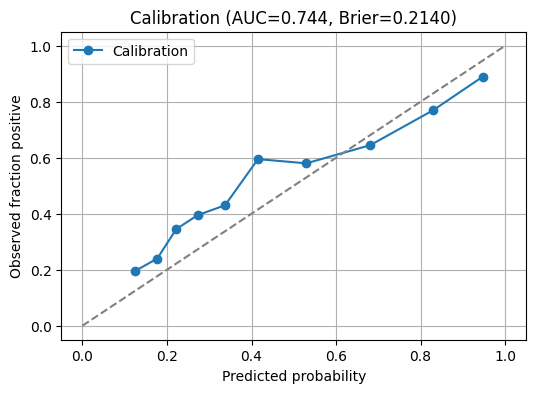

In [79]:


auc = roc_auc_score(y_hold, probs_hold)
brier = brier_score_loss(y_hold, probs_hold)
print("Holdout AUC:", auc, "Brier:", brier)

# calibration plot
prob_true, prob_pred = calibration_curve(y_hold, probs_hold, n_bins=10, strategy='quantile')
plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration')
plt.plot([0,1],[0,1], '--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('Observed fraction positive')
plt.title(f'Calibration (AUC={auc:.3f}, Brier={brier:.4f})')
plt.grid(True); plt.legend(); plt.show()